# PCA Anomaly Score

### How to measure?
For each point $X$, we calculate how far it is from the data center (mean $\mu$) in **each principal direction**:

* We take the difference: $X - \mu$
* We project it onto the eigenvector $e_j$ (this tells us how far along that direction)
* We square it and divide by the variance (eigenvalue $\lambda_j$) in that direction

Then we **add all these up**:

$$
\text{Score}(X) = \sum_{j=1}^d \frac{|(X - \mu) \cdot e_j|^2}{\lambda_j}
$$

This score is higher for points that deviate more in **low-variance directions**, and lower in high-variance directions — exactly what we want for spotting unusual data.

### How to compute this practically:

1. **Compute the covariance matrix** of your data — this captures the relationships between features.
2. **Find the principal components (eigenvectors)** by diagonalizing the covariance matrix.
3. **Rotate** your data into this new coordinate system (where features are uncorrelated).
4. **Standardize**: divide each direction by its standard deviation (this is the same as dividing by $\sqrt{\lambda_j}$).
5. For each data point, compute its **distance from the mean** in this new space.

   * This distance is the outlier score.

---

### Key insight:

* Directions with **small eigenvalues (low variance)** are more sensitive to unusual behavior.
* If a point deviates in those quiet directions, it may be an **outlier**.
* This method weights all directions (soft weighting), instead of dropping some (hard selection).
* * Keep **all** principal components.
* But give **less importance (less weight)** to directions where there's a lot of natural variation (high eigenvalue).
* Give **more importance** to directions where the data usually doesn't vary much — because deviations there are more suspicious.


## Visualization

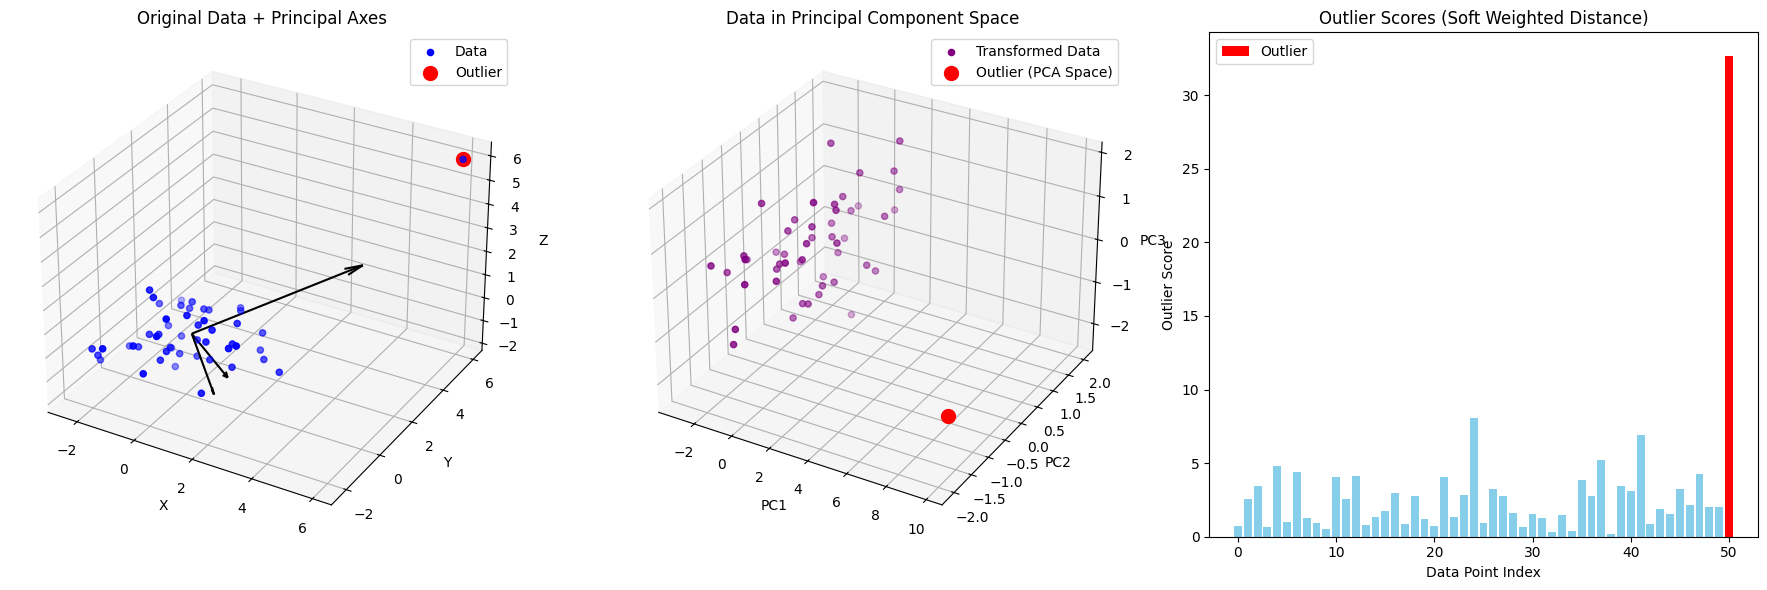

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Generate 3D synthetic data
np.random.seed(42)
n_points = 50

# Generate a 3D Gaussian blob
X = np.random.multivariate_normal(mean=[0, 0, 0], cov=[[2, 1, 0.5], [1, 1.5, 0.2], [0.5, 0.2, 1]], size=n_points)

# Add an outlier
outlier = np.array([[6, 6, 6]])
X = np.vstack([X, outlier])

# Step 2: Mean-center the data
mu = np.mean(X, axis=0)
X_centered = X - mu

# Step 3: SVD (same as PCA basis)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
eigenvectors = Vt.T
eigenvalues = S**2 / (len(X_centered) - 1)

# Step 4: Transform data to PCA space
X_pca = X_centered @ eigenvectors

# Step 5: Compute soft-weighted outlier score (Mahalanobis-like)
scores = np.sum((X_pca**2) / eigenvalues, axis=1)

# Step 6: 3D Plotting

fig = plt.figure(figsize=(18, 6))

# (A) Original Data with Principal Axes
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', label='Data')
ax1.scatter(outlier[0, 0], outlier[0, 1], outlier[0, 2], c='red', label='Outlier', s=100)
origin = mu

# Draw principal axes
for i in range(3):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 3
    ax1.quiver(*origin, *vec, color='black', arrow_length_ratio=0.1)

ax1.set_title("Original Data + Principal Axes")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.legend()

# (B) Transformed Data in PCA Space
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c='purple', label='Transformed Data')
ax2.scatter(X_pca[-1, 0], X_pca[-1, 1], X_pca[-1, 2], c='red', label='Outlier (PCA Space)', s=100)
ax2.set_title("Data in Principal Component Space")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.legend()

# (C) Outlier Scores (Bar Plot)
ax3 = fig.add_subplot(133)
ax3.bar(range(len(scores)), scores, color='skyblue')
ax3.bar(len(scores)-1, scores[-1], color='red', label='Outlier')
ax3.set_title("Outlier Scores (Soft Weighted Distance)")
ax3.set_xlabel("Data Point Index")
ax3.set_ylabel("Outlier Score")
ax3.legend()

plt.tight_layout()
plt.show()


In [ ]:
A/B

If B = 0, then A/B = inf

df['C'] = np.where(df['B']==0, 0, df['A']/df['B'])